In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from tqdm import tqdm
from itertools import combinations
import shap
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

# Demonstration on house price prediction

In [2]:
import decision_infovalue
import importlib
importlib.reload(decision_infovalue)

<module 'decision_infovalue' from '/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/__init__.py'>

In [3]:
df, _ = decision_infovalue.get_dataset("housing", with_human_data = False)
df = df[["SalePrice", "Year Built", "Exterior 1st", "Overall Qual", "Bedroom AbvGr"]]

encoder = OneHotEncoder()
encoder.fit_transform(df[["Exterior 1st"]])
cat = pd.DataFrame(data = encoder.transform(df[["Exterior 1st"]]).toarray(), columns = encoder.get_feature_names_out())
df = df.join(cat)

In [53]:
data_with_human, metadata = decision_infovalue.get_dataset("housing")
selected_features = ["Year Built", "Year Remod/Add", "Gr Liv Area", "Garage Cars", "Fireplaces", "Overall Qual"]
data_with_human = data_with_human[selected_features + ["SalePrice", "Order", "human_response", "is_train", "PROLIFIC_PID"]]

In [55]:
data_with_human

,Year Built,Year Remod/Add,Gr Liv Area,Garage Cars,Fireplaces,Overall Qual,SalePrice,Order,human_response,is_train,PROLIFIC_PID
0,1960,1960,1656,2.0,2,6,215000,1,NaN,True,NaN
1,1961,1961,896,1.0,0,5,105000,2,NaN,True,NaN
2,1958,1958,1329,1.0,0,6,172000,3,NaN,True,NaN
3,1968,1968,2110,2.0,2,7,244000,4,280.0,False,64d5067b6cbee9de481d773b
4,1968,1968,2110,2.0,2,7,244000,4,190.0,False,67001c01bcb0cabf8a7f01e7
...,...,...,...,...,...,...,...,...,...,...,...
3734,1983,1983,902,2.0,0,5,131000,2927,NaN,True,NaN
3735,1992,1992,970,0.0,0,5,132000,2928,100.0,False,6630fcae418bde6a9e7c3b47
3736,1992,1992,970,0.0,0,5,132000,2928,306.0,False,67ddf84df4607179bf8f6b22
3737,1974,1975,1389,2.0,1,5,170000,2929,NaN,True,NaN


In [4]:
np.random.seed(42)  # For reproducibility

msk = np.random.rand(len(df)) < 0.7

train_df = df[msk]
test_df = df[~msk]

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (2054, 21)
Testing set shape: (876, 21)


In [5]:
encoder.get_feature_names_out().tolist()

['Exterior 1st_AsbShng',
 'Exterior 1st_AsphShn',
 'Exterior 1st_BrkComm',
 'Exterior 1st_BrkFace',
 'Exterior 1st_CBlock',
 'Exterior 1st_CemntBd',
 'Exterior 1st_HdBoard',
 'Exterior 1st_ImStucc',
 'Exterior 1st_MetalSd',
 'Exterior 1st_Plywood',
 'Exterior 1st_PreCast',
 'Exterior 1st_Stone',
 'Exterior 1st_Stucco',
 'Exterior 1st_VinylSd',
 'Exterior 1st_Wd Sdng',
 'Exterior 1st_WdShing']

In [6]:

model_features = ["Year Built", "Bedroom AbvGr"] + encoder.get_feature_names_out().tolist()
params = {'lambda': 5.08745375747522, 'alpha': 1.3840557746026854, 'colsample_bytree': 0.3, 'subsample': 0.7, 
           'learning_rate': 0.0705794117436359, 'max_depth': 5, 'random_state': 1, 'min_child_weight': 9}
model = XGBRegressor(eval_metric='rmse', n_estimators=1433, enable_categorical=True, **params)
model.fit(train_df[model_features], train_df["Overall Qual"], verbose = False)
test_y = model.predict(test_df[model_features])
mse = mean_squared_error(test_y, test_df["Overall Qual"])
mape = mean_absolute_percentage_error(test_y, test_df["Overall Qual"])
r2 = r2_score(test_y, test_df["Overall Qual"])

print('---------test------------')
print("R²: %.2f" % r2)
print("MSE: %.2f" % mse)
print("RMSE: %.4f" % np.sqrt(mse))
print("MAPE: %.2f" % (mape * 100) + '%')

---------test------------
R²: 0.40
MSE: 0.76
RMSE: 0.8693
MAPE: 11.46%


In [7]:
# Fit linear regression model
linear_model = LinearRegression()
linear_features = ["Year Built", "Bedroom AbvGr"] + encoder.get_feature_names_out().tolist()
linear_model.fit(train_df[linear_features], np.log(train_df["SalePrice"]))

# Evaluate linear model performance
linear_test_y = np.exp(linear_model.predict(test_df[linear_features]))
linear_mse = mean_squared_error(np.log(linear_test_y), np.log(test_df["SalePrice"]))
linear_mape = mean_absolute_percentage_error(np.log(linear_test_y), np.log(test_df["SalePrice"])) 
linear_r2 = r2_score(np.log(linear_test_y), np.log(test_df["SalePrice"]))

print('---------Linear Model Test Results------------')
print("R²: %.2f" % linear_r2)
print("MSE: %.2f" % linear_mse) 
print("RMSE: %.4f" % np.sqrt(linear_mse))
print("MAPE: %.2f" % (linear_mape * 100) + '%')


---------Linear Model Test Results------------
R²: -0.18
MSE: 0.09
RMSE: 0.3007
MAPE: 1.91%


In [8]:
# Calculate SHAP values
explainer = shap.Explainer(model, seed=42)
shap_values = explainer.shap_values(df[model_features])

In [9]:
df["quality_pred"] = np.round(model.predict(df[model_features]), 0)
df["human_pred_sale_price"] = np.round(np.exp(linear_model.predict(df[linear_features]))/1000, 0) * 1000
# Add SHAP values as new columns in df
shap_columns = [f'shap_{col}' for col in model_features]
shap_df = pd.DataFrame(np.round(shap_values, 0), columns=[f'shap_{col}' for col in model_features])
df = pd.concat([df, shap_df], axis=1)

df

,SalePrice,Year Built,Exterior 1st,Overall Qual,Bedroom AbvGr,Exterior 1st_AsbShng,Exterior 1st_AsphShn,Exterior 1st_BrkComm,Exterior 1st_BrkFace,Exterior 1st_CBlock,...,shap_Exterior 1st_HdBoard,shap_Exterior 1st_ImStucc,shap_Exterior 1st_MetalSd,shap_Exterior 1st_Plywood,shap_Exterior 1st_PreCast,shap_Exterior 1st_Stone,shap_Exterior 1st_Stucco,shap_Exterior 1st_VinylSd,shap_Exterior 1st_Wd Sdng,shap_Exterior 1st_WdShing
0,215000,1960,BrkFace,6,3,0.0,0.0,0.0,1.0,0.0,...,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
1,105000,1961,VinylSd,5,2,0.0,0.0,0.0,0.0,0.0,...,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
2,172000,1958,Wd Sdng,6,3,0.0,0.0,0.0,0.0,0.0,...,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
3,244000,1968,BrkFace,7,3,0.0,0.0,0.0,1.0,0.0,...,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
4,189900,1997,VinylSd,5,3,0.0,0.0,0.0,0.0,0.0,...,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,142500,1984,HdBoard,6,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
2926,131000,1983,HdBoard,5,2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
2927,132000,1992,HdBoard,5,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
2928,170000,1974,HdBoard,5,2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0


In [14]:
info_model = decision_infovalue.DecisionInfoModel(df, "SalePrice", 
                                     signals=["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred", "human_pred_sale_price"] + shap_columns, 
                                     scoring_rule="mse",
                                     binning_method=None)
mpae_info_model = decision_infovalue.DecisionInfoModel(df, "SalePrice", 
                                     signals=["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred", "human_pred_sale_price"] + shap_columns, 
                                     scoring_rule=lambda action, state: -abs(action - state)/state,
                                     binning_method=None)

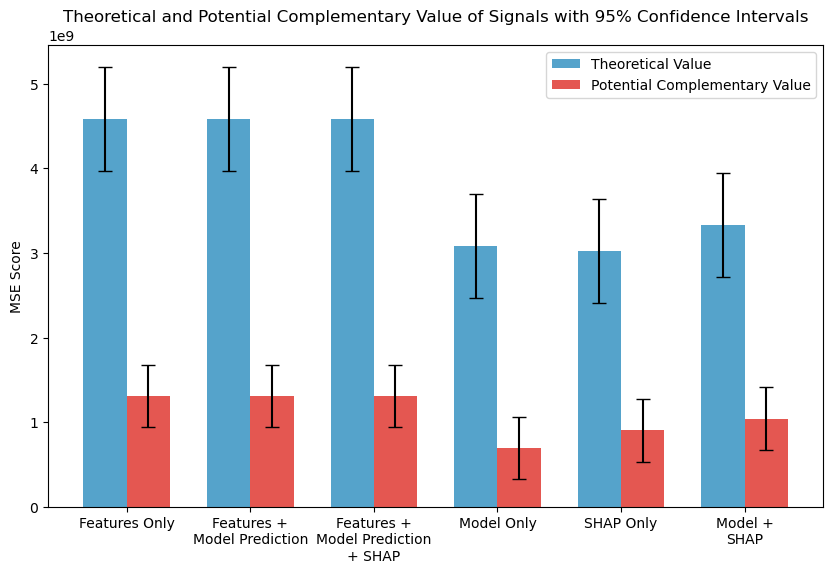

In [42]:
feature_score, feature_std = info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st"], [], ret_std=True)
model_score, model_std = info_model.complement_info_value(["quality_pred"], [], ret_std=True)
shap_score, shap_std = info_model.complement_info_value(shap_columns, [], ret_std=True)
model_shap_score, model_shap_std = info_model.complement_info_value(["quality_pred"] + shap_columns, [], ret_std=True)
feature_model_score, feature_model_std = info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"], [], ret_std=True)
feature_model_shap_score, feature_model_shap_std = info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"] + shap_columns, [], ret_std=True)

feature_complement_score, feature_complement_std = \
    info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st"], ["human_pred_sale_price"], ret_std=True)
model_complement_score, model_complement_std = \
    info_model.complement_info_value(["quality_pred"], ["human_pred_sale_price"], ret_std=True)
shap_complement_score, shap_complement_std = \
    info_model.complement_info_value(shap_columns, ["human_pred_sale_price"], ret_std=True)
model_shap_complement_score, model_shap_complement_std = \
    info_model.complement_info_value(["quality_pred"] + shap_columns, ["human_pred_sale_price"], ret_std=True)
feature_model_complement_score, feature_model_complement_std = \
    info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"], ["human_pred_sale_price"], ret_std=True)
feature_model_shap_complement_score, feature_model_shap_complement_std = \
    info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"] + shap_columns, ["human_pred_sale_price"], ret_std=True)
# Create bar chart comparing different feature scores with error bars
# Create bar chart comparing different feature scores with error bars
plt.figure(figsize=(10,6))

# Prepare data
scores_no_complement = [feature_score, feature_model_score, feature_model_shap_score, model_score, shap_score, model_shap_score]
scores_complement = [feature_complement_score, feature_model_complement_score, feature_model_shap_complement_score, model_complement_score, shap_complement_score, model_shap_complement_score]
stds_no_complement = [feature_std, feature_model_std, feature_model_shap_std, model_std, shap_std, model_shap_std]
stds_complement = [feature_complement_std, feature_model_complement_std, feature_model_shap_complement_std, model_complement_std, shap_complement_std, model_shap_complement_std]
labels = ['Features Only', 'Features +\nModel Prediction', 'Features +\nModel Prediction\n+ SHAP', 'Model Only', 'SHAP Only', 'Model +\nSHAP']

x = np.arange(len(scores_no_complement))
width = 0.35  # Width of the bars

# Create bars
plt.bar(x - width/2, scores_no_complement, width, yerr=1.96*np.array(stds_no_complement), capsize=5,
        alpha=0.8, label='Theoretical Value', color='#2b8cbe')
plt.bar(x + width/2, scores_complement, width, yerr=1.96*np.array(stds_complement), capsize=5,
        alpha=0.8, label='Potential Complementary Value', color='#de2d26')

plt.xticks(x, labels, rotation=0, ha='center')
plt.title('Theoretical and Potential Complementary Value of Signals with 95% Confidence Intervals')
plt.ylabel('MSE Score')
plt.legend()

plt.savefig('mse_value_comparison.pdf', bbox_inches='tight')


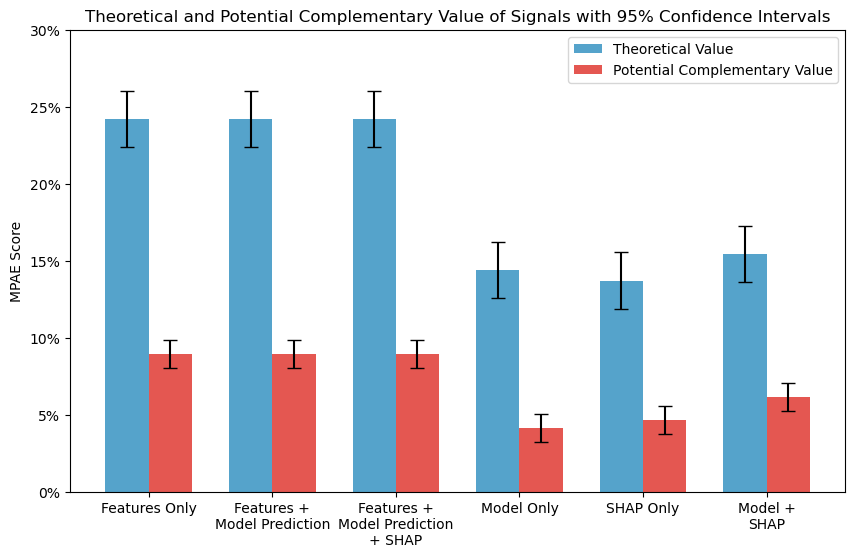

In [43]:
mpae_feature_score, mpae_feature_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st"], [], ret_std=True)
mpae_model_score, mpae_model_std = mpae_info_model.complement_info_value(["quality_pred"], [], ret_std=True)
mpae_shap_score, mpae_shap_std = mpae_info_model.complement_info_value(shap_columns, [], ret_std=True)
mpae_model_shap_score, mpae_model_shap_std = mpae_info_model.complement_info_value(["quality_pred"] + shap_columns, [], ret_std=True)
mpae_feature_model_score, mpae_feature_model_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"], [], ret_std=True)
mpae_feature_model_shap_score, mpae_feature_model_shap_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"] + shap_columns, [], ret_std=True)

mpae_feature_complement_score, mpae_feature_complement_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st"], ["human_pred_sale_price"], ret_std=True)
mpae_model_complement_score, mpae_model_complement_std = mpae_info_model.complement_info_value(["quality_pred"], ["human_pred_sale_price"], ret_std=True)
mpae_shap_complement_score, mpae_shap_complement_std = mpae_info_model.complement_info_value(shap_columns, ["human_pred_sale_price"], ret_std=True)
mpae_model_shap_complement_score, mpae_model_shap_complement_std = mpae_info_model.complement_info_value(["quality_pred"] + shap_columns, ["human_pred_sale_price"], ret_std=True)
mpae_feature_model_complement_score, mpae_feature_model_complement_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"], ["human_pred_sale_price"], ret_std=True)
mpae_feature_model_shap_complement_score, mpae_feature_model_shap_complement_std = mpae_info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st", "quality_pred"] + shap_columns, ["human_pred_sale_price"], ret_std=True)
# Create bar chart comparing different feature scores with error bars
plt.figure(figsize=(10,6))

# Prepare data
mpae_scores_no_complement = [mpae_feature_score, mpae_feature_model_score, mpae_feature_model_shap_score, mpae_model_score, mpae_shap_score, mpae_model_shap_score]
mpae_scores_complement = [mpae_feature_complement_score, mpae_feature_model_complement_score, mpae_feature_model_shap_complement_score, mpae_model_complement_score, mpae_shap_complement_score, mpae_model_shap_complement_score]
mpae_stds_no_complement = [mpae_feature_std, mpae_feature_model_std, mpae_feature_model_shap_std, mpae_model_std, mpae_shap_std, mpae_model_shap_std]
mpae_stds_complement = [mpae_feature_complement_std, mpae_feature_model_complement_std, mpae_feature_model_shap_complement_std, mpae_model_complement_std, mpae_shap_complement_std, mpae_model_shap_complement_std]
labels = ['Features Only', 'Features +\nModel Prediction', 'Features +\nModel Prediction\n+ SHAP', 'Model Only', 'SHAP Only', 'Model +\nSHAP']

x = np.arange(len(mpae_scores_no_complement))
width = 0.35  # Width of the bars

# Create bars
plt.bar(x - width/2, mpae_scores_no_complement, width, yerr=1.96*np.array(mpae_stds_no_complement), capsize=5,
        alpha=0.8, label='Theoretical Value', color='#2b8cbe')
plt.bar(x + width/2, mpae_scores_complement, width, yerr=1.96*np.array(mpae_stds_complement), capsize=5,
        alpha=0.8, label='Potential Complementary Value', color='#de2d26')

plt.xticks(x, labels, rotation=0, ha='center')
plt.yticks(plt.yticks()[0], [f'{x:.0%}' for x in plt.yticks()[0]])
plt.title('Theoretical and Potential Complementary Value of Signals with 95% Confidence Intervals')
plt.ylabel('MPAE Score')
plt.legend()
plt.savefig('mape_value_comparison.pdf', bbox_inches='tight')


In [42]:
info_model.complement_info_value(["Year Built", "Bedroom AbvGr", "Exterior 1st"], [])
info_model.complement_info_value(["quality_pred", "Year Built", "Bedroom AbvGr", "Exterior 1st"], [])

4580362903.585975

# Demonstration on Lai and Tan 2019

In [ ]:
import pandas as pd
from scipy import stats
import decision_infovalue

In [2]:
df = pd.concat([pd.read_csv(f'hotel_review_user_label_{i}.csv') for i in range(0, 2)]).reset_index(drop=True)

df

,anonymized_worker_id,experiment,total_time_in_minutes,user_label,actual_label,review_time_in_seconds,predicted_label,review_num,deceptive,positive,review_text,processed_text,cluster
0,5AB84043BCE99,control,10,0,0,N.A.,N.A.,1,0,0,"The Omni Chicago Hotel was in one word, dreadf...",omni chicago hotel one word dreadful hotel hea...,4
1,5AB84043BCE99,control,10,0,1,10,N.A.,7,1,0,We stay at the Palmer House when we attend con...,stay palmer house attend conference chicago st...,12
2,5AB84043BCE99,control,10,0,1,31,N.A.,8,1,0,I was surprised by the fact that there were no...,surprised fact extra sheet blanket make hide b...,12
3,5AB84043BCE99,control,10,0,1,14,N.A.,9,1,0,Three nights there on business. Hadn't realize...,three night business hadnt realized place cons...,17
4,5AB84043BCE99,control,10,0,1,22,N.A.,10,1,0,The Talbott Hotel itself is a bit worn around ...,talbott hotel bit worn around edge bit worn mu...,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,5AE8EB4045C1D,machine_and_random_heatmap,2,1,1,-1,1,8,1,0,The location is ideal. They have very high cei...,location ideal high ceiling room appear much l...,22
14396,5AE8EB4045C1D,machine_and_random_heatmap,2,1,0,-4,0,14,0,1,I stayed at Swissotel Chicago when I was on bu...,stayed swissotel chicago business nice staff h...,20
14397,5AE8EB4045C1D,machine_and_random_heatmap,2,1,1,-3,1,16,1,1,The Omni Chicago really delivers on all fronts...,omni chicago really delivers front spaciousnes...,32
14398,5AE8EB4045C1D,machine_and_random_heatmap,2,1,1,-4,1,19,1,1,I recently stayed at this hotel with my family...,recently stayed hotel family terrific experien...,24


In [39]:
experiment_condition = df["experiment"].unique()

result = {}
full_infovalue = 0
for condition in experiment_condition:
    df_condition = df.loc[df["experiment"] == condition]
    info_model = decision_infovalue.DecisionInfoModel(df_condition, "actual_label", 
                                     signals=["cluster", "user_label", "predicted_label"], 
                                     scoring_rule="accuracy",
                                     ra_agg_func="mode",
                                     binning_method=None)
    result[condition] = {
        "theoretical_value": info_model.complement_info_value(["cluster"], [], ret_std=True),
        "potential_complementary_value": info_model.complement_info_value(["cluster"], ["user_label"], ret_std=True)
    }
    full_infovalue = max(full_infovalue, info_model.full_info_value - info_model.no_info_value)

print(result)
print(full_infovalue)

{'control': {'theoretical_value': (0.16374999999999995, 0.011814332290365248), 'potential_complementary_value': (0.15312499999999996, 0.011814332290365248)}, 'highlight': {'theoretical_value': (0.17874999999999996, 0.01167756403862435), 'potential_complementary_value': (0.11937500000000001, 0.01167756403862435)}, 'heatmap': {'theoretical_value': (0.15312500000000007, 0.011898069737447888), 'potential_complementary_value': (0.07750000000000001, 0.011898069737447888)}, 'examples': {'theoretical_value': (0.16749999999999998, 0.011781408860858563), 'potential_complementary_value': (0.12312499999999993, 0.011781408860858563)}, 'machine_with_accuracy': {'theoretical_value': (0.260625, 0.010670885541194358), 'potential_complementary_value': (0.015000000000000013, 0.010670885541194358)}, 'machine': {'theoretical_value': (0.18000000000000005, 0.011665549843801786), 'potential_complementary_value': (0.06125000000000003, 0.011665549843801786)}, 'machine_and_heatmap': {'theoretical_value': (0.2406

In [40]:
experiment_condition_machine = ["machine_and_random_heatmap", "machine_and_examples", "machine_and_heatmap", "machine_with_accuracy"]
baseline_performance = np.mean(df.loc[df["experiment"] == "machine"]["actual_label"] == df.loc[df["experiment"] == "machine"]["user_label"])
for condition in experiment_condition_machine:
    df_condition = df.loc[df["experiment"] == condition]
    behavioral_performance = np.mean(df_condition["actual_label"] == df_condition["user_label"])
    behavioral_performance_std = stats.sem(df_condition["actual_label"] == df_condition["user_label"])
    result[condition]["behavioral_value"] = (behavioral_performance - baseline_performance, behavioral_performance_std)

result

{'control': {'theoretical_value': (0.16374999999999995, 0.011814332290365248),
  'potential_complementary_value': (0.15312499999999996,
   0.011814332290365248)},
 'highlight': {'theoretical_value': (0.17874999999999996, 0.01167756403862435),
  'potential_complementary_value': (0.11937500000000001, 0.01167756403862435)},
 'heatmap': {'theoretical_value': (0.15312500000000007, 0.011898069737447888),
  'potential_complementary_value': (0.07750000000000001,
   0.011898069737447888)},
 'examples': {'theoretical_value': (0.16749999999999998, 0.011781408860858563),
  'potential_complementary_value': (0.12312499999999993,
   0.011781408860858563)},
 'machine_with_accuracy': {'theoretical_value': (0.260625,
   0.010670885541194358),
  'potential_complementary_value': (0.015000000000000013,
   0.010670885541194358),
  'behavioral_value': (0.12687499999999996, 0.010891136770189182)},
 'machine': {'theoretical_value': (0.18000000000000005, 0.011665549843801786),
  'potential_complementary_value':

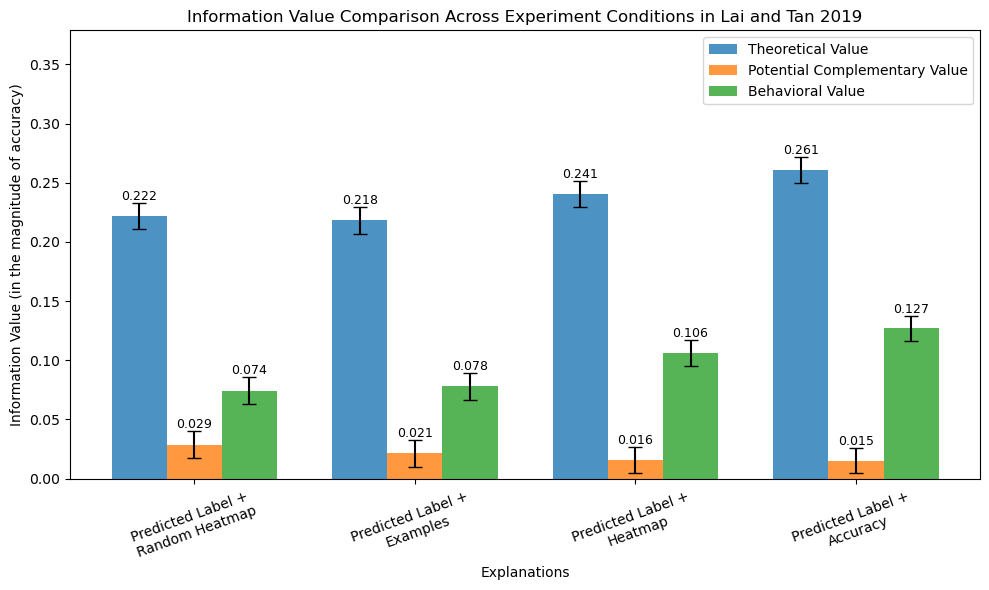

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
conditions = ["machine_and_random_heatmap", "machine_and_examples", "machine_and_heatmap", "machine_with_accuracy"] # list(result.keys())
theoretical_values = [result[condition]["theoretical_value"][0] for condition in conditions]
theoretical_stds = [result[condition]["theoretical_value"][1] for condition in conditions]
potential_values = [result[condition]["potential_complementary_value"][0] for condition in conditions]
potential_stds = [result[condition]["potential_complementary_value"][1] for condition in conditions]
behavioral_values = [result[condition]["behavioral_value"][0] for condition in conditions]
behavioral_stds = [result[condition]["behavioral_value"][1] for condition in conditions]

# Set up the bar plot
x = np.arange(len(conditions))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, theoretical_values, width, label='Theoretical Value', 
               yerr=theoretical_stds, capsize=5, alpha=0.8)
bars2 = ax.bar(x, potential_values, width, label='Potential Complementary Value', 
               yerr=potential_stds, capsize=5, alpha=0.8)
bars3 = ax.bar(x + width, behavioral_values, width, label='Behavioral Value', 
               yerr=behavioral_stds, capsize=5, alpha=0.8)
ax.tick_params(axis='x', rotation=20)

# Customize the plot
ax.set_xlabel('Explanations')
ax.set_ylabel('Information Value (in the magnitude of accuracy)')
ax.set_title('Information Value Comparison Across Experiment Conditions in Lai and Tan 2019')
ax.set_xticks(x)
ax.set_xticklabels(["Predicted Label + \nRandom Heatmap", "Predicted Label + \nExamples", "Predicted Label + \nHeatmap", "Predicted Label + \nAccuracy"])
ax.legend()

# Set y-axis range to [0, full_infovalue]
ax.set_ylim(0, full_infovalue)


# Add value labels on top of bars
for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    height3 = bar3.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + theoretical_stds[i],
            f'{height1:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + potential_stds[i],
            f'{height2:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar3.get_x() + bar3.get_width()/2., height3 + behavioral_stds[i],
            f'{height3:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lai_and_tan_2019.pdf', bbox_inches='tight')
plt.show()
